In [29]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from optuna.integration import TFKerasPruningCallback
import tensorflow as tf
import numpy as np
from sklearn.metrics import roc_auc_score

In [28]:
!pip install optuna-integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 3.4 MB/s eta 0:00:00


In [2]:
df=pd.read_csv('/kaggle/input/datasets/mominulhoque/02-14-2018/02-14-2018.csv')

In [3]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [4]:
df.shape

(1048575, 80)

In [5]:
df['Label'].value_counts()

Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64

In [6]:
df.isnull().sum()

Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64

In [7]:
col=df.columns
col

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [8]:
df=df.drop(columns='Timestamp')

In [9]:
zero_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
zero_variance_cols

['Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'CWE Flag Count',
 'Fwd Byts/b Avg',
 'Fwd Pkts/b Avg',
 'Fwd Blk Rate Avg',
 'Bwd Byts/b Avg',
 'Bwd Pkts/b Avg',
 'Bwd Blk Rate Avg']

In [10]:
df=df.drop(columns=zero_variance_cols)

In [11]:
zero_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
zero_variance_cols

[]

In [12]:
inf_nan_cols = df.columns[
    (df.isin([np.inf, -np.inf]).any(axis=0)) | (df.isna().any(axis=0))
]

print(inf_nan_cols)

Index(['Flow Byts/s', 'Flow Pkts/s'], dtype='object')


In [13]:
df['Flow Byts/s'] = df['Flow Byts/s'].replace([np.inf, -np.inf], np.nan)
df['Flow Pkts/s'] = df['Flow Pkts/s'].replace([np.inf, -np.inf], np.nan)

In [14]:
df['Flow Byts/s'] = df['Flow Byts/s'].fillna(0)
df['Flow Pkts/s'] = df['Flow Pkts/s'].fillna(0)

In [15]:
inf_nan_cols = df.columns[
    (df.isin([np.inf, -np.inf]).any(axis=0)) | (df.isna().any(axis=0))
]

print(inf_nan_cols)

Index([], dtype='object')


In [ ]:
# # 2. Create a separate column for binary classification 
# # This preserves the original 'Label' for your df_attack filtering
# df['Label'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

# # 3. Filter using the original labels
# df_benign = df[df['Label'] == 'Benign']
# df_attack = df[df['Label'] != 'Benign']

# # Now these will work:
# print(df_benign.shape)
# print(df_attack['Label'].value_counts())

In [17]:
# 1. Convert labels to numeric (0 for Benign, 1 for everything else)
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

# 2. Filter using the NEW numeric labels
df_benign = df[df['Label'] == 0]
df_attack = df[df['Label'] == 1]

# Verify the shapes before splitting
print(f"Benign samples: {df_benign.shape[0]}")
print(f"Attack samples: {df_attack.shape[0]}")

# 3. Now the split will work
df_benign_train, df_benign_val = train_test_split(df_benign, test_size=0.20, random_state=42)

# 4. Construct the TRAIN Set (Normal Data only for Autoencoder)
X_train = df_benign_train.drop(columns=['Label'])

# 5. Construct the VALIDATION Set (Mixed)
df_val_mixed = pd.concat([df_benign_val, df_attack])
df_val_mixed = df_val_mixed.sample(frac=1, random_state=42).reset_index(drop=True)

Benign samples: 667626
Attack samples: 380949


In [18]:
y_val = df_val_mixed['Label'].values
X_val = df_val_mixed.drop(columns=['Label'])

In [19]:
print(f"Training Set (Pure Benign): {X_train.shape[0]} rows")
print(f"Validation Set (Mixed): {X_val.shape[0]} rows")

Training Set (Pure Benign): 534100 rows
Validation Set (Mixed): 514475 rows


In [20]:
print("\n--- Step 2: Data Scaling ---")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Take a 20% subsample of the training data strictly for fast Optuna tuning
X_tune_benign, _ = train_test_split(X_train_scaled, train_size=0.20, random_state=42)
print(f"Tuning Optuna on a fast subsample of {X_tune_benign.shape[0]} benign flows.")


--- Step 2: Data Scaling ---
Tuning Optuna on a fast subsample of 106820 benign flows.


In [21]:
print("\n--- Step 3: Optuna Hyperparameter Tuning ---")
def build_autoencoder(latent_dim, learning_rate, input_dim):
    encoder_input = layers.Input(shape=(input_dim,))
    x = layers.Dense(32, activation='relu')(encoder_input)
    x = layers.Dense(latent_dim, activation='relu')(x) # Bottleneck
    x = layers.Dense(32, activation='relu')(x)
    decoder_output = layers.Dense(input_dim, activation='linear')(x)
    
    model = models.Model(inputs=encoder_input, outputs=decoder_output)
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model


--- Step 3: Optuna Hyperparameter Tuning ---


In [22]:
def objective_ae(trial):
    tf.keras.backend.clear_session()
    
    latent_dim = trial.suggest_categorical("latent_dim", [8, 12, 16, 24])
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    
    ae_tune = build_autoencoder(latent_dim, learning_rate, X_tune_benign.shape[1])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    pruning_callback = TFKerasPruningCallback(trial, "val_loss")
    
    ae_tune.fit(
        X_tune_benign, X_tune_benign,
        epochs=10, batch_size=batch_size, validation_split=0.2,
        callbacks=[early_stop, pruning_callback], verbose=0
    )
    
    # Evaluate using the mixed validation set and the saved y_val
    val_predictions = ae_tune.predict(X_val_scaled, verbose=0)
    val_mse = np.mean(np.power(X_val_scaled - val_predictions, 2), axis=1)
    
    return roc_auc_score(y_val, val_mse)

In [25]:
import optuna

In [30]:
pruner = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2)
study_ae = optuna.create_study(direction="maximize", pruner=pruner)
study_ae.optimize(objective_ae, n_trials=15, show_progress_bar=True)

[I 2026-04-01 19:40:16,105] A new study created in memory with name: no-name-595ea8e0-13cb-4dfb-b87d-ecded5151a47


  0%|          | 0/15 [00:00<?, ?it/s]

I0000 00:00:1775072417.739740     272 service.cc:152] XLA service 0x79ef4c0252a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775072417.739786     272 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775072417.739790     272 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775072418.176204     272 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775072419.387577     272 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[I 2026-04-01 19:41:08,668] Trial 0 finished with value: 0.9715999161402822 and parameters: {'latent_dim': 12, 'learning_rate': 0.00018651761994206752, 'batch_size': 128}. Best is trial 0 with value: 0.9715999161402822.
[I 2026-04-01 19:41:53,599] Trial 1 finished with value: 0.9836821209313733 and parameters: {'latent_dim': 12, 'learning_rate': 0.0025306874848284463, 'batch_size': 256}. Best is trial 1 with value: 0.9836821209313733.
[I 2026-04-01 19:42:38,194] Trial 2 finished with value: 0.932269141575449 and parameters: {'latent_dim': 16, 'learning_rate': 0.00020420595354431903, 'batch_size': 256}. Best is trial 1 with value: 0.9836821209313733.
[I 2026-04-01 19:43:20,384] Trial 3 finished with value: 0.9759563033505053 and parameters: {'latent_dim': 24, 'learning_rate': 0.0009034750826500495, 'batch_size': 512}. Best is trial 1 with value: 0.9836821209313733.
[I 2026-04-01 19:44:04,517] Trial 4 finished with value: 0.9703078262238433 and parameters: {'latent_dim': 16, 'learning_ra

In [31]:
best_ae_params = study_ae.best_trial.params
print("Best parameters successfully saved for final training!")
print(best_ae_params)

Best parameters successfully saved for final training!
{'latent_dim': 12, 'learning_rate': 0.0033514905381503398, 'batch_size': 512}


In [32]:
print("\n--- Training Final Optimized Autoencoder ---")

# 1. Clear memory before the big run
tf.keras.backend.clear_session()

# 2. Build the model using the winning parameters from Optuna
ae_final = build_autoencoder(
    latent_dim=best_ae_params['latent_dim'], 
    learning_rate=best_ae_params['learning_rate'], 
    input_dim=X_train_scaled.shape[1]
)

# 3. Use EarlyStopping to prevent overfitting
early_stop_final = EarlyStopping(
    monitor='val_loss', 
    patience=4, 
    restore_best_weights=True
)

# 4. Train on the FULL pure benign dataset
history = ae_final.fit(
    X_train_scaled, X_train_scaled,
    epochs=50, # Let it run until early stopping triggers
    batch_size=best_ae_params['batch_size'], 
    validation_split=0.1,
    callbacks=[early_stop_final],
    verbose=1
)

print("\nFinal Autoencoder training complete!")


--- Training Final Optimized Autoencoder ---
Epoch 1/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0157 - val_loss: 4.7277e-04
Epoch 2/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.9243e-04 - val_loss: 2.4721e-04
Epoch 3/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1672e-04 - val_loss: 1.4346e-04
Epoch 4/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.3127e-04 - val_loss: 1.1838e-04
Epoch 5/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1369e-04 - val_loss: 1.0376e-04
Epoch 6/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.0331e-04 - val_loss: 9.5214e-05
Epoch 7/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.5085e-05 - val_loss: 8.6488e-05
Epoch 8/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.9245e-05 - val_loss: 8.4054e-05
Epoch 9/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.4468e-05 - val_loss: 7.6438e-05
Epoch 10/50
939/939 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.2232e-05 - val_loss: 6.5190e-05
Epoch 11/50
939/9


--- Setting Threshold & Final Evaluation ---
16078/16078 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step
Optimal Reconstruction Error Threshold: 0.000062

--- Final Model Performance (On Validation Set) ---
Accuracy: 0.9870
F1 Score: 0.9913
ROC-AUC:  0.9961

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    133526
           1       0.98      1.00      0.99    380949

    accuracy                           0.99    514475
   macro avg       0.99      0.97      0.98    514475
weighted avg       0.99      0.99      0.99    514475



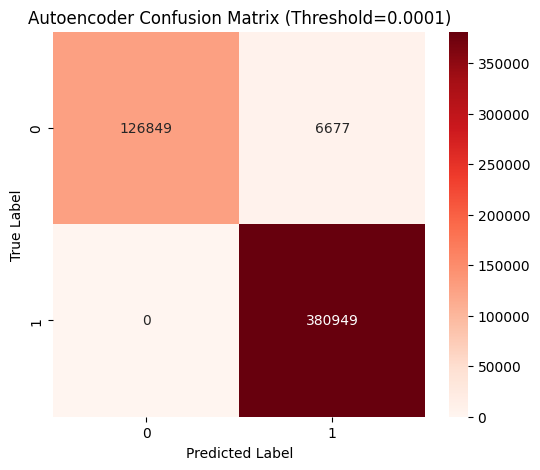

In [33]:
print("\n--- Setting Threshold & Final Evaluation ---")

# 1. Predict on the mixed validation set
val_predictions_final = ae_final.predict(X_val_scaled)
val_mse_final = np.mean(np.power(X_val_scaled - val_predictions_final, 2), axis=1)

# 2. Find the 95th percentile of MSE for ONLY the benign traffic in the validation set
# This allows a 5% false positive rate to maximize catching real attacks
val_benign_mse = val_mse_final[y_val == 0]
optimal_threshold = np.percentile(val_benign_mse, 95)
print(f"Optimal Reconstruction Error Threshold: {optimal_threshold:.6f}")

# 3. Classify as attack (1) if the error is greater than our threshold
y_val_pred_ae = (val_mse_final > optimal_threshold).astype(int)

# 4. Output final metrics
print("\n--- Final Model Performance (On Validation Set) ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_ae):.4f}")
print(f"F1 Score: {f1_score(y_val, y_val_pred_ae):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_val, val_mse_final):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_ae))

# 5. Plot the Final Confusion Matrix
cm_ae = confusion_matrix(y_val, y_val_pred_ae)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ae, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Autoencoder Confusion Matrix (Threshold={optimal_threshold:.4f})")
plt.show()

In [35]:
df_test_new = pd.read_csv('/kaggle/input/datasets/mominulhoque/02-16-2018/02-16-2018.csv')

/tmp/ipykernel_180/3935301491.py:1: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_test_new = pd.read_csv('/kaggle/input/datasets/mominulhoque/02-16-2018/02-16-2018.csv')


In [36]:
df_test_new.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,16/02/2018 08:27:23,112640768,3,0,0,0,0,0,...,0,0,0.0,0,0,56300000.0,138.592929,56300000,56300000,Benign
1,0,0,16/02/2018 08:30:12,112641773,3,0,0,0,0,0,...,0,0,0.0,0,0,56300000.0,263.750829,56300000,56300000,Benign
2,35605,6,16/02/2018 08:26:55,20784143,23,44,2416,1344,240,64,...,20,2624734,0.0,2624734,2624734,9058214.0,0.0,9058214,9058214,Benign
3,0,0,16/02/2018 08:33:01,112640836,3,0,0,0,0,0,...,0,0,0.0,0,0,56300000.0,82.024387,56300000,56300000,Benign
4,23,6,16/02/2018 08:27:59,20,1,1,0,0,0,0,...,20,0,0.0,0,0,0.0,0.0,0,0,Benign


In [38]:
df_test_new['Label'].value_counts()

Label
DoS attacks-Hulk            461912
Benign                      446772
DoS attacks-SlowHTTPTest    139890
Label                            1
Name: count, dtype: int64

In [41]:
df_test_new = df_test_new[df_test_new['Label'] != 'Label']

In [42]:
df_test_new['Label'].value_counts()

Label
DoS attacks-Hulk            461912
Benign                      446772
DoS attacks-SlowHTTPTest    139890
Name: count, dtype: int64

In [43]:
df_test_new_col=df.columns
df_test_new_col

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max',
       'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt',
       'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
       'URG Flag Cnt', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts',
       'Subflow Fwd Byts', '

In [44]:
df_test_new=df_test_new.drop(columns='Timestamp')

In [45]:
zero_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
zero_variance_cols

[]

In [46]:
inf_nan_cols = df.columns[
    (df.isin([np.inf, -np.inf]).any(axis=0)) | (df.isna().any(axis=0))
]

print(inf_nan_cols)

Index([], dtype='object')


In [48]:
cols = list(df.columns)
test_cols = list(df_test_new.columns)

if cols == test_cols:
    print("Columns match exactly")
else:
    print("Columns do NOT match")

    print("\nColumns missing in test dataset:")
    print(set(cols) - set(test_cols))

    print("\nExtra columns in test dataset:")
    print(set(test_cols) - set(cols))

Columns do NOT match

Columns missing in test dataset:
set()

Extra columns in test dataset:
{'Fwd Byts/b Avg', 'Fwd Blk Rate Avg', 'Fwd URG Flags', 'Bwd URG Flags', 'Bwd Pkts/b Avg', 'Fwd Pkts/b Avg', 'CWE Flag Count', 'Bwd Blk Rate Avg', 'Bwd PSH Flags', 'Bwd Byts/b Avg'}


In [51]:
# Remove extra columns
df_test_new = df_test_new[[col for col in cols if col in df_test_new.columns]]

# Add missing columns
for col in cols:
    if col not in df_test_new.columns:
        df_test_new[col] = 0

# Reorder columns
df_test_new = df_test_new[cols]

print("Test dataset columns fixed")

Test dataset columns fixed


In [53]:
cols = list(df.columns)
test_cols = list(df_test_new.columns)

if cols == test_cols:
    print("Columns match exactly")
else:
    print("Columns do NOT match")

    print("\nColumns missing in test dataset:")
    print(set(cols) - set(test_cols))

    print("\nExtra columns in test dataset:")
    print(set(test_cols) - set(cols))

Columns match exactly


In [54]:
df_test_new['Label'] = df_test_new['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

In [55]:
y_test_final = df_test_new['Label'].values
X_test_raw = df_test_new.drop(columns=['Label'])

In [56]:
X_test_scaled_final = scaler.transform(X_test_raw)

print(f"Test data perfectly formatted! Shape: {X_test_scaled_final.shape}")

Test data perfectly formatted! Shape: (1048574, 68)


In [57]:
test_predictions = ae_final.predict(X_test_scaled_final)

32768/32768 ━━━━━━━━━━━━━━━━━━━━ 40s 1ms/step


In [60]:
test_mse = np.mean(np.power(X_test_scaled_final - test_predictions, 2), axis=1)

In [61]:
y_test_pred_final = (test_mse > optimal_threshold).astype(int)

Accuracy: 0.5741
F1 Score: 0.7294
ROC-AUC:  0.1108

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.00      0.00    446772
           1       0.57      1.00      0.73    601802

    accuracy                           0.57   1048574
   macro avg       0.79      0.50      0.37   1048574
weighted avg       0.76      0.57      0.42   1048574



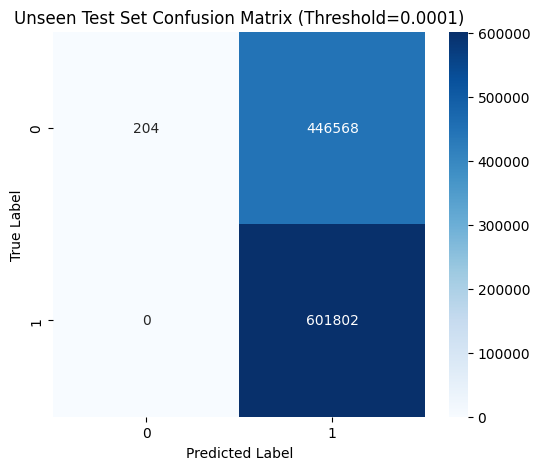

In [62]:
print(f"Accuracy: {accuracy_score(y_test_final, y_test_pred_final):.4f}")
print(f"F1 Score: {f1_score(y_test_final, y_test_pred_final):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test_final, test_mse):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test_final, y_test_pred_final))

# 9. Plot the Final Confusion Matrix
cm_test = confusion_matrix(y_test_final, y_test_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Unseen Test Set Confusion Matrix (Threshold={optimal_threshold:.4f})")
plt.show()